## Fall Risk Prediction Using Machine Learning and SHAP Explainability


This notebook develops and evaluates multiple machine‑learning models to predict 
the percentage of long‑stay residents experiencing one or more falls with major injury. 
The analysis includes data preprocessing, model comparison, selection of the best model, 
and SHAP explainability to identify the strongest predictors of fall risk.

In [17]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
import joblib


## Data Loading and Preprocessing

The cleaned dataset (`df_final.csv`) is loaded and split into training and testing sets. 
Predictors are standardized using `StandardScaler` to ensure consistent scaling across models.


loading data

In [2]:
df = pd.read_csv("df_final.csv")
df.head()

,num_facilities,overall_rating,rn_hours_total,staff_turnover_pct,total_fines,total_payment_denials,hosp_per_1000_residents,falls_with_injury,pressure_ulcers,uti_pct,catheter_pct,mobility_decline_pct,restrained_pct,incontinence_pct,weight_loss_pct,depression_pct
0,7.0,2.2,0.7,51.4,5.0,0.0,1.8,4.7,5.1,2.8,2.1,17.5,0.1,22.4,4.8,24.7
1,6.0,2.3,0.5,34.8,5.0,6.0,2.5,1.6,3.9,0.1,0.0,6.6,0.1,4.2,3.1,7.4
2,16.0,2.5,0.5,34.5,14.0,3.0,2.8,1.6,5.7,1.3,0.6,9.4,0.0,10.8,4.2,20.6
3,7.0,1.3,0.5,49.5,6.0,0.0,1.3,2.7,5.6,2.0,1.6,27.4,0.0,26.7,7.7,8.7
4,5.0,3.6,0.4,47.8,0.0,0.0,1.3,3.6,4.1,0.9,0.3,13.6,0.0,18.5,5.6,3.8


Defining target and predictor variables

In [3]:
target = "falls_with_injury"
X = df.drop(columns=[target])
y = df[target]


Train Test Split

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
X_train_df = pd.DataFrame(X_train, columns=X.columns)
X_test_df = pd.DataFrame(X_test, columns=X.columns)

y_train_df = pd.DataFrame(y_train, columns=["falls_with_injury"])
y_test_df = pd.DataFrame(y_test, columns=["falls_with_injury"])

X_train_df.to_csv("X_train.csv", index=False)
X_test_df.to_csv("X_test.csv", index=False)
y_train_df.to_csv("y_train.csv", index=False)
y_test_df.to_csv("y_test.csv", index=False)


Scaling Predictors

In [8]:

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Defining Models

In [11]:
models = {
    "Linear Regression": LinearRegression(),
    "Lasso Regression": Lasso(alpha=0.01),
    "Ridge Regression": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(n_estimators=500, random_state=42),
    "XGBoost": XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    ),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "Extra Trees": ExtraTreesRegressor(n_estimators=500, random_state=42),
    "KNN Regressor": KNeighborsRegressor(n_neighbors=5)
}



## Model Training and Evaluation

Eight machine‑learning models were trained using standardized predictors. 
Performance was evaluated using RMSE and R² on the test set.


Training and evaluating the models

In [ ]:
results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)

    mse = mean_squared_error(y_test, preds)
    rmse = mse ** 0.5
    r2 = r2_score(y_test, preds)

    results.append([name, rmse, r2])

results_df = pd.DataFrame(results, columns=["Model", "RMSE", "R²"])
results_df = results_df.sort_values(by="RMSE")

print("\n=== MODEL PERFORMANCE COMPARISON ===")
print(results_df.to_string(index=False))


=== MODEL PERFORMANCE COMPARISON ===
            Model     RMSE        R²
      Extra Trees 1.157724  0.159984
    Random Forest 1.172583  0.138283
Gradient Boosting 1.194354  0.105986
 Lasso Regression 1.220956  0.065719
 Ridge Regression 1.236373  0.041975
Linear Regression 1.237127  0.040806
          XGBoost 1.237453  0.040301
    KNN Regressor 1.295168 -0.051309


Saving the best model

In [18]:
joblib.dump(models["Extra Trees"], "best_model_extra_trees.pkl")
joblib.dump(scaler, "scaler.pkl")


['scaler.pkl']

## SHAP Explainability

SHAP was applied to the Extra Trees model to identify the most influential predictors 
and visualize their effects on fall‑risk predictions.


Shap Explainability

/Users/charity/Desktop/AI FALL RISK PREDICTION/tenv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


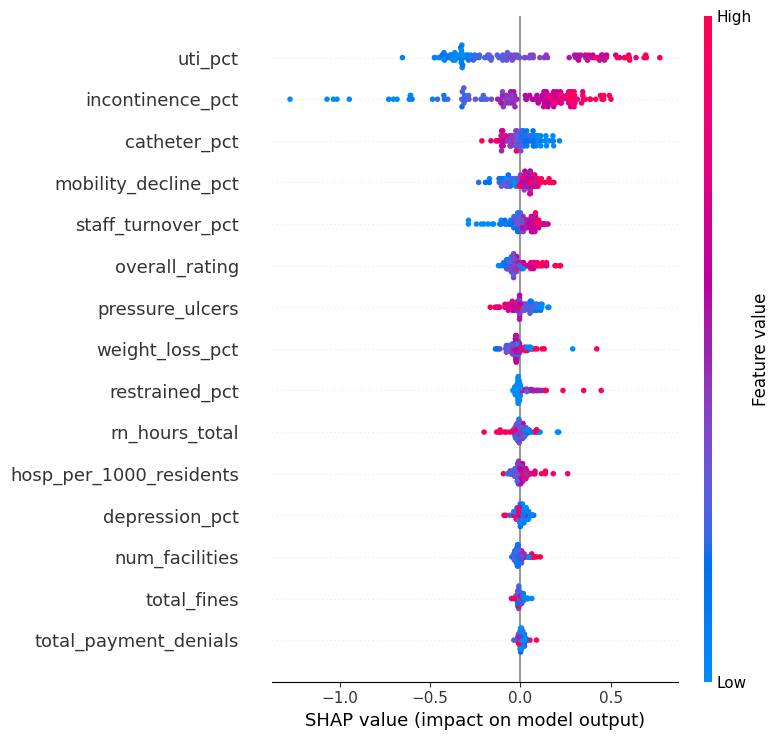

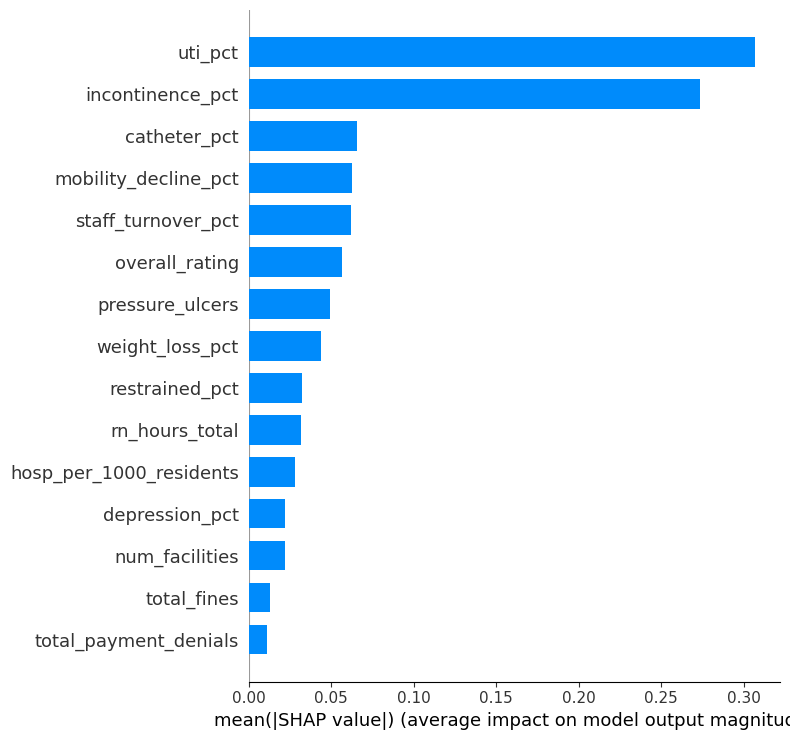

In [21]:
import shap

best_model = models["Extra Trees"]

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test_scaled)

# Summary plot
shap.summary_plot(shap_values, X_test, plot_type="dot")

# Bar plot
shap.summary_plot(shap_values, X_test, plot_type="bar")


Dependency plots

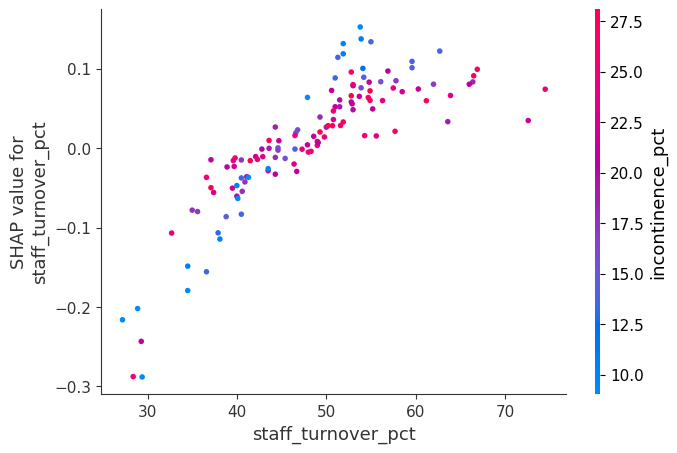

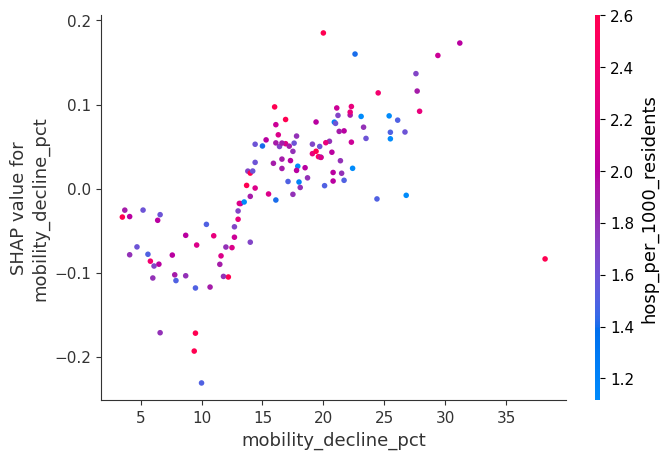

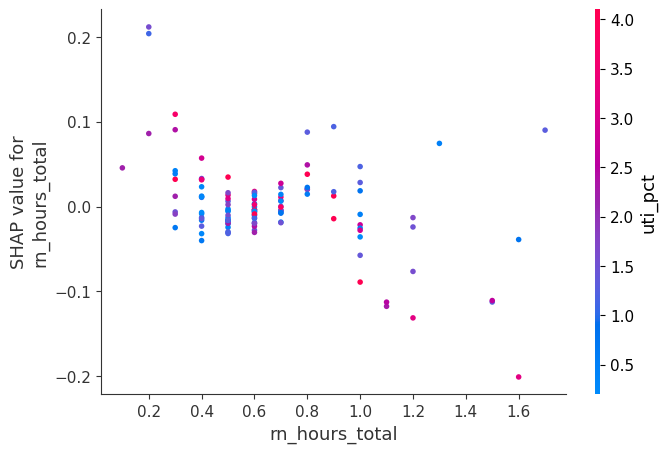

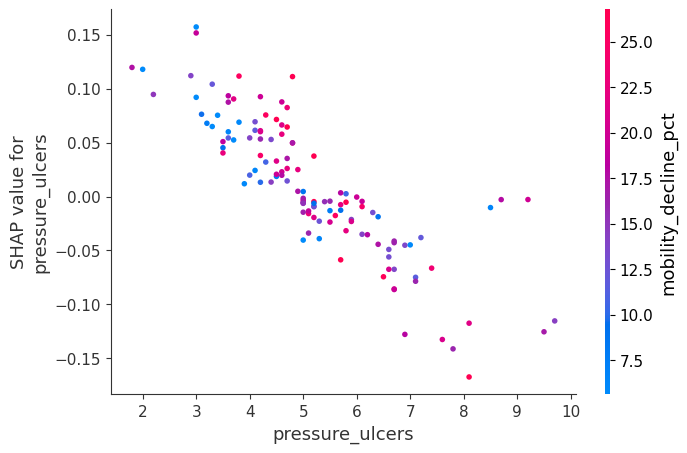

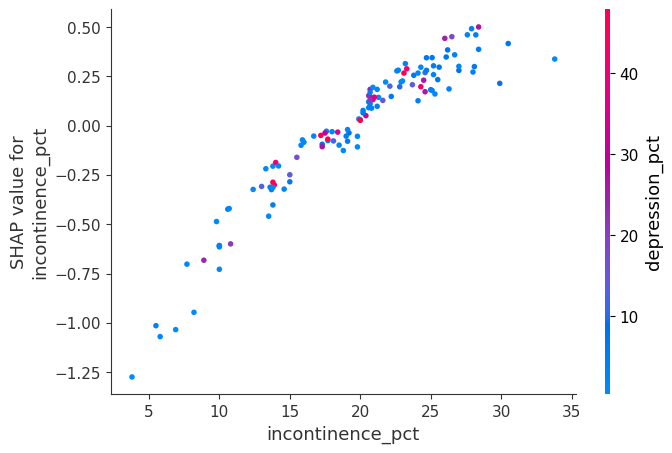

In [22]:
shap.dependence_plot("staff_turnover_pct", shap_values, X_test)
shap.dependence_plot("mobility_decline_pct", shap_values, X_test)
shap.dependence_plot("rn_hours_total", shap_values, X_test)
shap.dependence_plot("pressure_ulcers", shap_values, X_test)
shap.dependence_plot("incontinence_pct", shap_values, X_test)


## Results
### Model Performance
Eight machine‑learning models were trained and evaluated using an 80/20 train–test split with standardized predictors. Performance was assessed using root mean squared error (RMSE) and coefficient of determination (R²). Among all models, the Extra Trees Regressor achieved the strongest performance (RMSE = 1.16, R² = 0.16), outperforming Random Forest (RMSE = 1.17, R² = 0.14) and Gradient Boosting (RMSE = 1.19, R² = 0.11). Linear models and KNN demonstrated substantially weaker performance, indicating that fall‑risk patterns in this dataset are non‑linear and benefit from ensemble‑based tree methods.
The superior performance of Extra Trees suggests that the additional randomness introduced during tree construction improves generalization and reduces variance, making it well‑suited for complex, noisy, and correlated healthcare data.
### Global Feature Importance (SHAP Summary Plot)
SHAP analysis revealed a clear ranking of predictors influencing fall‑risk predictions. The top contributors were:
uti_pct (Urinary Tract Infection Rate)
incontinence_pct
catheter_pct
mobility_decline_pct
staff_turnover_pct
overall_rating
pressure_ulcers
weight_loss_pct.
Higher values of UTI rate, incontinence, catheter use, mobility decline, and staff turnover were associated with increased predicted fall risk. In contrast, higher overall facility ratings tended to reduce fall risk, indicating a protective effect.
These patterns highlight the multifactorial nature of fall risk, with both clinical and operational variables contributing meaningfully.
### Feature Effects (SHAP Dependence Patterns)
Dependence plots revealed several clinically and operationally relevant relationships:
uti_pct: Higher UTI prevalence sharply increased predicted fall risk.
incontinence_pct: Higher incontinence rates were strongly associated with elevated risk.
catheter_pct: Catheter use showed a monotonic positive relationship with fall risk.
mobility_decline_pct: Fall risk increased non‑linearly as mobility decline worsened.
staff_turnover_pct: Elevated turnover was associated with higher fall risk, underscoring the importance of staffing stability.
pressure_ulcers: Higher pressure ulcer rates tended to decrease SHAP values, suggesting complex interactions with mobility and care quality.
### Interpretation
The Extra Trees model provided the most accurate and stable predictions and offered interpretable insights into the drivers of fall risk. SHAP analysis confirmed that fall risk in long‑term care settings is influenced by a combination of clinical conditions (UTIs, incontinence, catheter use, pressure ulcers), functional decline (mobility loss, weight loss), and operational factors (staff turnover, facility rating).
These results support the use of ensemble‑based machine‑learning models for fall‑risk surveillance and highlight actionable targets for intervention, including infection control, continence management, mobility support, and workforce stability.
